R²=0.062 | p=0.0189 | corr=0.248


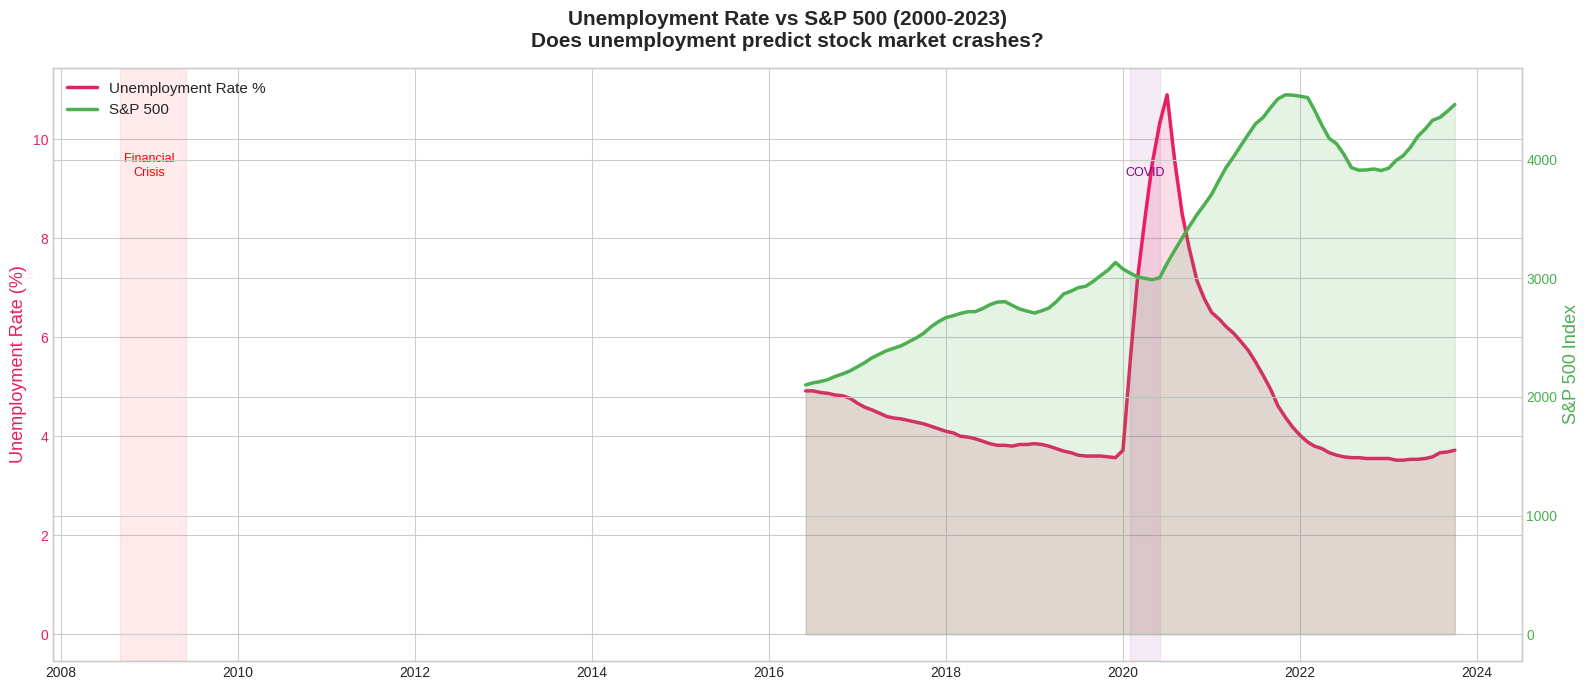

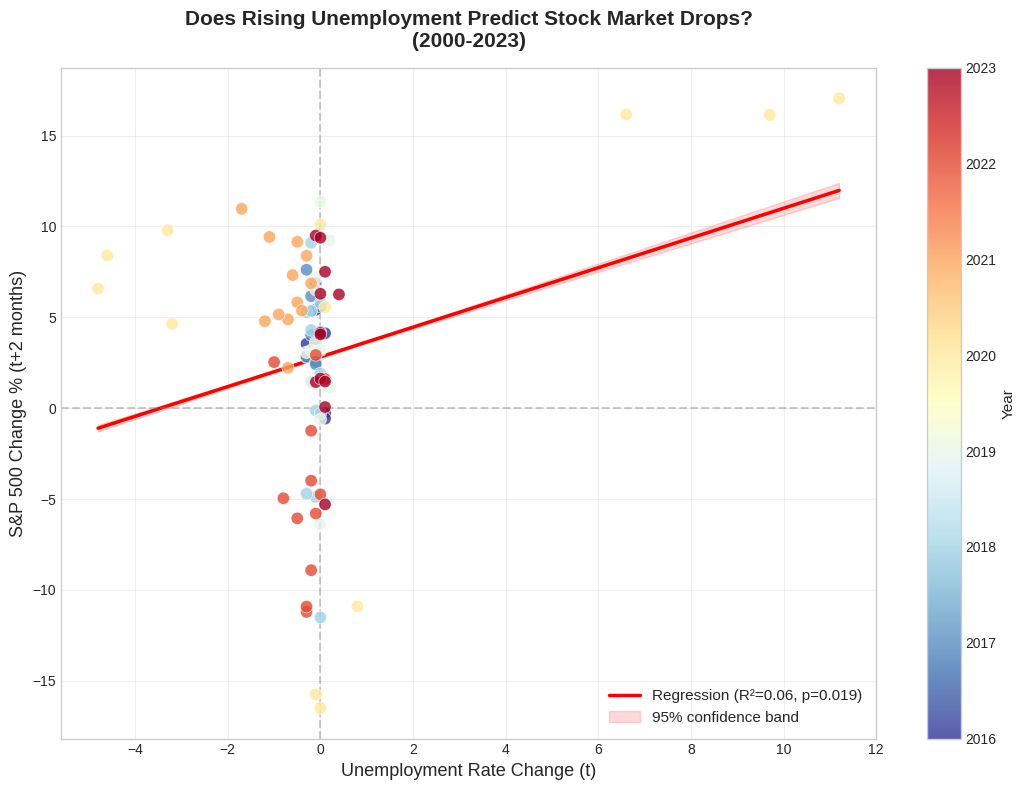

IndexError: single positional indexer is out-of-bounds

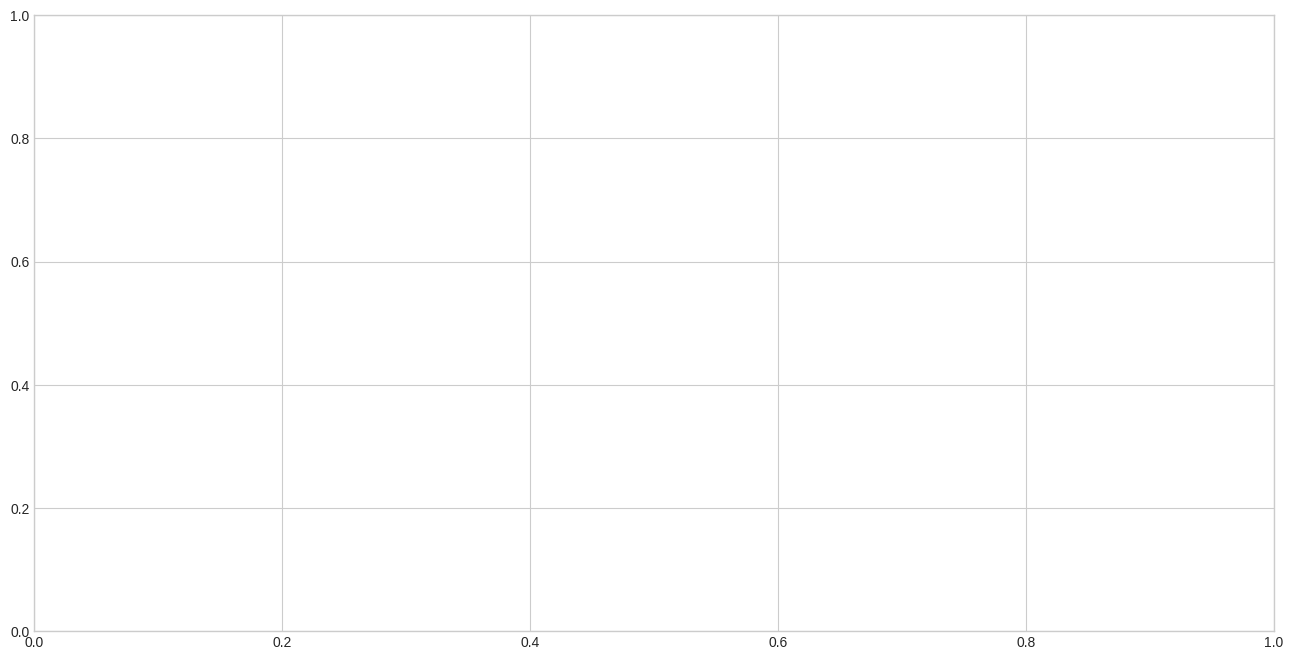

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import pandas_datareader as pdr
import datetime

plt.style.use('seaborn-v0_8-whitegrid')

START = datetime.datetime(2000, 1, 1)
END = datetime.datetime(2023, 12, 31)

# Pull data
unemp = pdr.get_data_fred('UNRATE', start=START, end=END)
sp500 = pdr.get_data_fred('SP500', start=START, end=END)

unemp_m = unemp.resample('MS').mean()
sp500_m = sp500.resample('MS').mean()

df = unemp_m.join(sp500_m, how='inner').dropna()
df.columns = ['unemployment', 'sp500']

df['unemp_change'] = df['unemployment'].diff(3)
df['sp500_change'] = df['sp500'].pct_change(3) * 100
df['unemp_smooth'] = df['unemployment'].rolling(6, center=True).mean()
df['sp500_smooth'] = df['sp500'].rolling(6, center=True).mean()
df['unemp_lag'] = df['unemp_change'].shift(2)
clean = df[['unemp_lag', 'sp500_change']].dropna()

slope, intercept, r, p, std_err = stats.linregress(clean['unemp_lag'], clean['sp500_change'])
print(f"R²={r**2:.3f} | p={p:.4f} | corr={clean['unemp_lag'].corr(clean['sp500_change']):.3f}")

# ══════════════════════════════════════════════════════════
# CHART 1: Dual axis overview
# ══════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(16, 7))
ax2 = ax1.twinx()

ax1.fill_between(df.index, df['unemp_smooth'], alpha=0.15, color='#E91E63')
ax2.fill_between(df.index, df['sp500_smooth'], alpha=0.15, color='#4CAF50')
ax1.plot(df.index, df['unemp_smooth'], color='#E91E63', linewidth=2.5, label='Unemployment Rate %')
ax2.plot(df.index, df['sp500_smooth'], color='#4CAF50', linewidth=2.5, label='S&P 500')

# Key events
ax1.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'), alpha=0.08, color='red')
ax1.text(pd.Timestamp('2009-01-01'), df['unemp_smooth'].max()*0.85,
         'Financial\nCrisis', fontsize=9, color='red', ha='center')
ax1.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), alpha=0.08, color='purple')
ax1.text(pd.Timestamp('2020-04-01'), df['unemp_smooth'].max()*0.85,
         'COVID', fontsize=9, color='purple', ha='center')

ax1.set_ylabel('Unemployment Rate (%)', color='#E91E63', fontsize=13)
ax2.set_ylabel('S&P 500 Index', color='#4CAF50', fontsize=13)
ax1.tick_params(axis='y', colors='#E91E63')
ax2.tick_params(axis='y', colors='#4CAF50')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=11)
plt.title('Unemployment Rate vs S&P 500 (2000-2023)\nDoes unemployment predict stock market crashes?',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('unemp_vs_sp500.png', dpi=200, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# CHART 2: Scatter + regression
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 8))

years = clean.index.year
sc = ax.scatter(clean['unemp_lag'], clean['sp500_change'],
                c=years, cmap='RdYlBu_r', s=80, alpha=0.8,
                edgecolors='white', linewidth=0.5, zorder=3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year', fontsize=11)

x_line = np.linspace(clean['unemp_lag'].min(), clean['unemp_lag'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', linewidth=2.5,
        label=f'Regression (R²={r**2:.2f}, p={p:.3f})')

n = len(clean)
se = std_err * np.sqrt(1/n + (x_line - clean['unemp_lag'].mean())**2 /
                        ((n-1) * clean['unemp_lag'].std()**2))
ax.fill_between(x_line, y_line - 1.96*se, y_line + 1.96*se,
                alpha=0.15, color='red', label='95% confidence band')

ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Unemployment Rate Change (t)', fontsize=13)
ax.set_ylabel('S&P 500 Change % (t+2 months)', fontsize=13)
ax.set_title('Does Rising Unemployment Predict Stock Market Drops?\n(2000-2023)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unemp_sp500_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# CHART 3: Early warning zoom 2008-2010
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 8))

zoom = df.loc['2007':'2011'].copy()
zoom['unemp_norm'] = zoom['unemployment'] - zoom['unemployment'].iloc[0]
zoom['sp500_norm'] = (zoom['sp500'] - zoom['sp500'].iloc[0]) / zoom['sp500'].iloc[0] * 100

ax.plot(zoom.index, zoom['unemp_norm'], color='#E91E63', linewidth=3,
        label='Unemployment Change (pp)', zorder=3)
ax.plot(zoom.index, zoom['sp500_norm'], color='#4CAF50', linewidth=3,
        label='S&P 500 Change (%)', zorder=3)
ax.fill_between(zoom.index, zoom['unemp_norm'], alpha=0.1, color='#E91E63')
ax.fill_between(zoom.index, zoom['sp500_norm'], alpha=0.1, color='#4CAF50')

ax.axvline(pd.Timestamp('2008-09-01'), color='#4CAF50', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('S&P 500 crashes\n(Lehman Brothers)',
            xy=(pd.Timestamp('2008-09-01'), zoom['sp500_norm'].min()*0.5),
            xytext=(pd.Timestamp('2009-06-01'), zoom['sp500_norm'].min()*0.6),
            fontsize=10, color='#4CAF50', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=1.5))

ax.axvline(pd.Timestamp('2009-10-01'), color='#E91E63', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('Unemployment\npeaks at 10%',
            xy=(pd.Timestamp('2009-10-01'), zoom['unemp_norm'].max()*0.9),
            xytext=(pd.Timestamp('2010-04-01'), zoom['unemp_norm'].max()*0.9),
            fontsize=10, color='#E91E63', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1.5))

ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-10-01'),
           alpha=0.08, color='orange')
ax.text(pd.Timestamp('2009-02-01'), ax.get_ylim()[0]*0.6,
        '~13 month\nlag', fontsize=9, color='orange',
        fontweight='bold', ha='center')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Change from baseline', fontsize=13)
ax.legend(fontsize=12, loc='lower left')
ax.grid(True, alpha=0.25)
plt.title('Unemployment vs S&P 500 — 2008 Financial Crisis\nStock market crashed first, unemployment followed',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('unemp_early_warning.png', dpi=200, bbox_inches='tight')
plt.show()

print("=" * 50)
print("UNEMPLOYMENT → S&P 500 SUMMARY")
print("=" * 50)
print(f"Observations: {len(clean)}")
print(f"R² = {r**2:.3f}  ({r**2*100:.1f}% variance explained)")
print(f"p-value = {p:.4f}  ({'SIGNIFICANT' if p < 0.05 else 'not significant'} at 5% level)")
print(f"Slope = {slope:.3f}")
print(f"Correlation = {clean['unemp_lag'].corr(clean['sp500_change']):.3f}")
print("=" * 50)